<a href="https://colab.research.google.com/github/Ravindran-M/img-classify-CNN/blob/main/Efficientnetv2-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow
import matplotlib.pyplot as plt
import numpy as np
from tensorflow import keras

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
IMG_SIZE=(256,256,3)
premodel=keras.applications.EfficientNetV2L(
    include_top=False,
    weights="imagenet",
    input_tensor=None,
    input_shape=IMG_SIZE,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
    include_preprocessing=True,
)

473176280/473176280 ━━━━━━━━━━━━━━━━━━━━ 22s 0us/step


In [5]:
premodel.trainable=False


premodel.summary()


Model: "efficientnetv2-l"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 256, 256, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling (Rescaling)     │ (None, 256, 256, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 128, 128, 32)   │            864 │ rescaling[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 128, 128, 32)   │            128 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 128, 128, 32)   │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_project_conv      │ (None, 128, 128, 32)   │          9,216 │ stem_activation[0][0]  │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_project_bn        │ (None, 128, 128, 32)   │            128 │ block1a_project_conv[… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_project_activati… │ (None, 128, 128, 32)   │              0 │ block1a_project_bn[0]… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_add (Add)         │ (None, 128, 128, 32)   │              0 │ block1a_project_activ… │
│                           │                        │                │ stem_activation[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1b_project_conv      │ (None, 128, 128, 32)   │          9,216 │ block1a_add[0][0]      │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1b_project_bn        │ (None, 128, 128, 32)   │            128 │ block1b_project_conv[… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1b_project_activati… │ (None, 128, 128, 32)   │              0 │ block1b_project_bn[0]… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1b_drop (Dropout)    │ (None, 128, 128, 32)   │              0 │ block1b_project_activ… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1b_add (Add)         │ (None, 128, 128, 32)   │              0 │ block1b_drop[0][0],    │
│                           │                        │                │ block1a_add[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1c_project_conv 

 Total params: 117,746,848 (449.17 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 117,746,848 (449.17 MB)

In [6]:
model= keras.Sequential()
model.add(premodel)
model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(512,activation='relu'))
model.add(keras.layers.Dense(4,activation='softmax'))

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetv2-l (Functional)        │ (None, 8, 8, 1280)          │     117,746,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 81920)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      41,943,552 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │           2,052 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 159,692,452 (609.18 MB)

 Trainable params: 41,945,604 (160.01 MB)

 Non-trainable params: 117,746,848 (449.17 MB)

In [7]:
(train_ds),(test_ds)= keras.utils.image_dataset_from_directory(
    directory='drive/MyDrive/BrainMRIimage',
    labels='inferred',
    label_mode='int',
    validation_split=0.2,
    subset='both',
    seed=42,
    batch_size=32,
    shuffle=True,

)



Found 3096 files belonging to 4 classes.
Using 2477 files for training.
Using 619 files for validation.


In [ ]:
class_names = train_ds.class_names
print(class_names)

['glioma_tumor', 'meningioma_tumor', 'normal', 'pituitary_tumor']


In [ ]:
print(len(train_ds))
print(len(test_ds))

78
20


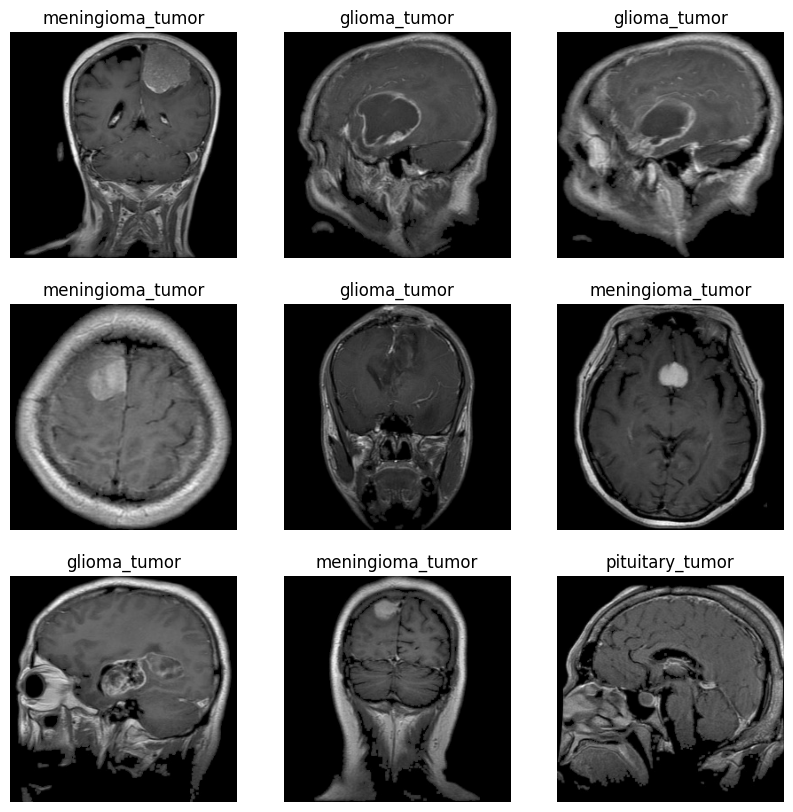

In [ ]:


plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [8]:
model.compile(optimizer='adam',
              loss=keras.losses.SparseCategoricalCrossentropy,
              metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetv2-l (Functional)        │ (None, 8, 8, 1280)          │     117,746,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 81920)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      41,943,552 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │           2,052 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 159,692,452 (609.18 MB)

 Trainable params: 41,945,604 (160.01 MB)

 Non-trainable params: 117,746,848 (449.17 MB)

In [9]:
history = model.fit(train_ds, epochs=20, validation_data=(test_ds))

Epoch 1/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 935s 11s/step - accuracy: 0.5232 - loss: 15.9245 - val_accuracy: 0.7981 - val_loss: 0.7153
Epoch 2/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 68s 465ms/step - accuracy: 0.8146 - loss: 0.6418 - val_accuracy: 0.8239 - val_loss: 0.6073
Epoch 3/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 41s 468ms/step - accuracy: 0.8486 - loss: 0.5068 - val_accuracy: 0.8449 - val_loss: 0.5115
Epoch 4/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 41s 471ms/step - accuracy: 0.8897 - loss: 0.3190 - val_accuracy: 0.8691 - val_loss: 0.3759
Epoch 5/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 38s 427ms/step - accuracy: 0.9261 - loss: 0.2051 - val_accuracy: 0.8821 - val_loss: 0.3723
Epoch 6/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 42s 442ms/step - accuracy: 0.9420 - loss: 0.1635 - val_accuracy: 0.8885 - val_loss: 0.3511
Epoch 7/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 44s 483ms/step - accuracy: 0.9549 - loss: 0.1258 - val_accuracy: 0.8708 - val_loss: 0.4185
Epoch 8/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 34s 439ms/step - accuracy: 0.9311 - loss: 0.1946 - val_accu

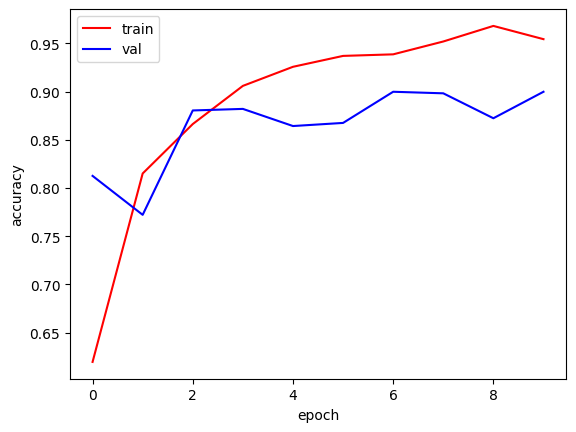

In [ ]:
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='val')
plt.legend()
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

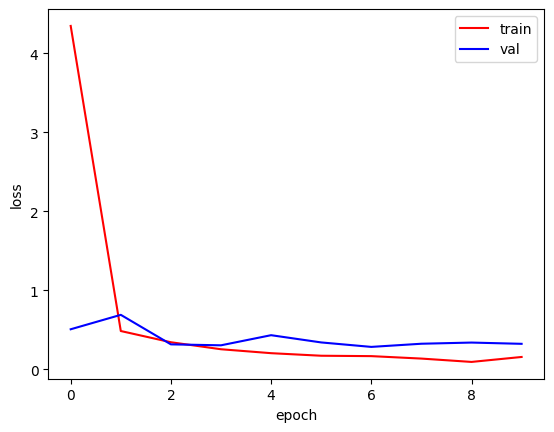

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
predictions = model.predict(test_ds)
predicted_labels = np.argmax(predictions, axis=1)  # Get predicted labels for all samples
true_labels = []

# Extract true labels from the test dataset
for images, labels in test_ds:
    true_labels.extend(labels.numpy())

true_labels = np.array(true_labels)

accuracy=accuracy_score(true_labels, predicted_labels)
print(f'Accuracy: {accuracy}')
precision = precision_score(true_labels, predicted_labels, average='weighted')
print(f'Precision: {precision}')
recall= recall_score(true_labels, predicted_labels, average='weighted')
print(f'Recall: {recall}')
f1_score= f1_score(true_labels, predicted_labels, average='weighted')
print(f'F1 Score: {f1_score}')
confusion_matrix= confusion_matrix(true_labels, predicted_labels)
print(f'Confusion Matrix:\n{confusion_matrix}')

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 360ms/step
Accuracy: 0.8998384491114702
Precision: 0.9025348229653752
Recall: 0.8998384491114702
F1 Score: 0.899971697601542
Confusion Matrix:
[[145  22   4   2]
 [  9 174   6   6]
 [  0   4  69   0]
 [  1   7   1 169]]


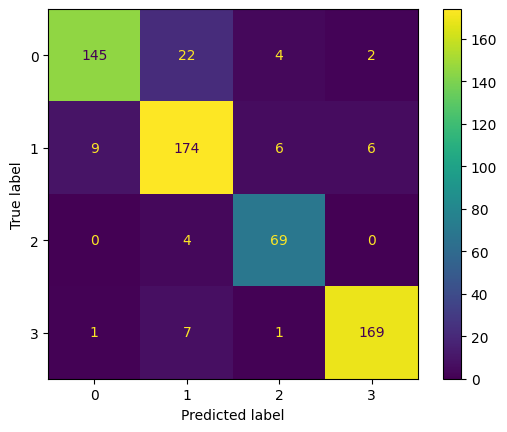

In [ ]:
from sklearn import metrics
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix)
cm_display.plot()
plt.show()

In [ ]:
print(predicted_labels)

[0 1 1 1 0 1 1 0 3 3 2 3 2 1 0 0 3 1 3 3 3 1 0 0 3 0 0 3 1 3 3 2 1 1 0 0 1
 0 3 2 1 1 3 3 2 1 0 1 2 3 1 1 1 0 0 0 0 3 1 3 3 1 3 2 1 1 1 3 0 0 3 0 0 3
 3 0 0 3 0 3 1 3 0 1 3 2 0 2 1 2 0 3 3 1 0 3 2 3 2 1 1 2 3 2 0 0 0 1 1 0 0
 3 0 1 3 0 2 0 3 1 0 3 1 1 1 1 3 3 3 1 3 3 1 0 2 0 0 3 1 1 0 1 2 3 3 1 3 1
 2 0 3 1 1 0 3 3 3 3 1 3 1 1 2 1 3 3 1 1 0 3 0 1 0 1 0 0 0 1 1 0 1 3 1 1 2
 1 3 0 0 3 2 1 1 2 0 2 3 3 1 0 0 1 3 1 0 0 1 1 0 1 3 3 3 1 0 2 3 3 3 3 2 1
 0 0 0 2 2 1 3 1 3 2 0 3 0 3 3 0 1 0 3 0 3 1 2 2 0 1 3 0 0 1 3 0 1 1 3 3 1
 0 2 1 2 2 0 3 2 1 1 0 1 0 0 1 0 1 3 1 1 3 3 3 1 3 2 1 0 3 0 0 3 3 0 1 3 0
 2 2 1 3 3 3 2 1 0 0 1 3 3 1 3 0 1 1 1 1 3 0 3 1 0 1 1 3 1 2 2 2 0 3 3 1 0
 1 1 0 0 0 1 2 2 0 1 3 1 2 3 0 3 3 2 0 3 0 3 3 1 0 1 1 2 2 3 1 0 3 3 3 2 0
 2 1 0 1 2 1 3 1 3 0 1 1 0 1 0 1 1 2 0 3 0 0 0 0 1 0 3 1 1 1 3 1 3 1 1 3 1
 0 1 3 1 0 2 0 1 1 3 3 1 2 1 3 1 2 0 0 1 0 0 1 1 0 1 1 2 3 3 1 1 1 2 2 2 1
 1 1 3 3 1 1 0 3 1 3 3 3 2 1 1 3 1 0 1 3 3 3 1 2 0 1 0 3 0 1 3 2 1 0 1 3 0
 0 3 3 1 3 1 3 1 1 3 2 3 

In [ ]:
print(true_labels)

[0 1 1 1 0 1 1 0 3 3 2 3 2 1 0 0 3 1 3 3 3 0 0 0 3 0 0 3 1 3 3 2 1 1 0 0 1
 0 3 2 1 1 3 3 2 1 1 1 2 3 1 1 1 1 0 0 0 3 1 3 3 1 1 2 1 1 1 3 0 0 3 0 0 3
 3 0 0 3 0 3 2 3 0 1 3 2 0 2 1 2 0 3 3 1 0 3 2 3 1 1 1 2 3 2 0 0 0 1 1 0 0
 0 0 1 3 0 2 0 3 1 0 3 0 1 1 1 3 3 3 1 3 3 1 0 2 0 0 3 1 0 0 1 1 3 3 1 3 1
 2 0 3 1 1 0 3 3 3 3 1 3 1 1 2 1 1 3 1 1 0 3 0 1 0 1 0 0 0 1 1 0 0 3 1 1 2
 1 3 0 0 3 2 1 1 0 0 0 3 3 3 0 0 0 0 1 0 0 1 1 0 1 3 3 3 1 0 0 1 3 3 3 2 1
 0 0 0 2 2 0 1 1 3 2 1 3 0 3 3 0 0 0 3 0 3 1 2 2 0 1 3 0 0 1 3 0 1 0 3 3 1
 0 3 1 2 2 0 3 2 1 3 0 1 1 0 0 0 0 3 3 1 3 3 3 1 3 2 1 0 3 0 0 3 3 1 1 3 0
 0 2 1 3 3 3 2 1 1 0 1 3 3 0 3 1 1 1 3 1 3 1 3 1 0 1 1 3 0 2 2 2 0 3 3 0 0
 1 1 1 0 0 1 2 2 0 1 3 1 2 3 0 3 1 2 0 3 0 3 3 1 0 1 1 2 2 3 1 0 3 3 3 2 0
 2 1 0 1 2 1 3 3 3 0 1 3 0 1 0 2 3 2 0 3 0 0 0 0 0 0 3 1 1 1 3 1 3 1 1 3 1
 0 1 3 0 0 2 0 1 1 3 3 1 2 1 3 1 2 0 0 1 0 0 1 1 0 1 1 1 3 3 1 1 1 2 1 2 1
 1 1 3 3 1 1 0 3 1 3 3 3 2 1 1 3 1 0 1 3 3 3 1 2 0 1 0 3 0 1 3 2 1 0 0 3 0
 0 3 3 1 3 1 3 1 1 3 2 3 

In [ ]:
print(test_ds.class_names[0])

glioma_tumor


In [10]:
premodel.trainable=True
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetv2-l (Functional)        │ (None, 8, 8, 1280)          │     117,746,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 81920)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      41,943,552 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │           2,052 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 243,583,662 (929.20 MB)

 Trainable params: 159,179,876 (607.22 MB)

 Non-trainable params: 512,576 (1.96 MB)

 Optimizer params: 83,891,210 (320.02 MB)

In [11]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4),loss=keras.losses.sparse_categorical_crossentropy,metrics=['accuracy'])

In [ ]:
history1=model.fit(train_ds,epochs=20,validation_data=test_ds)

Epoch 1/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 677s 4s/step - accuracy: 0.7351 - loss: 1.6593 - val_accuracy: 0.9095 - val_loss: 0.2656
Epoch 2/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.9474 - loss: 0.1437 - val_accuracy: 0.9289 - val_loss: 0.2206
Epoch 3/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9817 - loss: 0.0707 - val_accuracy: 0.9402 - val_loss: 0.1842
Epoch 4/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.9835 - loss: 0.0489 - val_accuracy: 0.9435 - val_loss: 0.2014
Epoch 5/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.9858 - loss: 0.0439 - val_accuracy: 0.9451 - val_loss: 0.2190
Epoch 6/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.9937 - loss: 0.0215 - val_accuracy: 0.9451 - val_loss: 0.2456
Epoch 7/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.9944 - loss: 0.0182 - val_accuracy: 0.9451 - val_loss: 0.2675
Epoch 8/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.9893 - loss: 0.0287 - val_accuracy: 0.9225 - v